In [29]:
import gzip
import json
import tabulate
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
def parse_benchmark_to_dataframe(root_dir: str) -> pd.DataFrame:
    root = Path(root_dir)
    metadata_path = root / "metadata.json"
    
    with metadata_path.open("r") as f:
        meta_list = json.load(f)

    rows = []
    
    for idx, meta in enumerate(meta_list):
        exp_dir = root / str(idx)
        if not exp_dir.is_dir():
            continue
            
        row = {
            "id": idx,
            "vpn": meta.get("vpn", "Unknown"),
            "delay": meta.get("delay", "0ms"),
            "jitter": meta.get("jitter", "0ms"),
            "loss": meta.get("loss", "0%"),
            "cpu_freq": meta.get("cpu_freq", "Unknown"),
            "core_count": meta.get("core_count", 0),
            "throughput_mbps": np.nan, 
            "avg_cpu_sar": np.nan,
            "ping_p99": np.nan,
            "ping_mean": np.nan
        }
        
        # 1. IPERF
        iperf_file = exp_dir / "iperf.json"
        if iperf_file.exists():
            try:
                iperf_data = json.loads(iperf_file.read_text())
                if "end" in iperf_data:
                    bps = iperf_data["end"].get("sum_received", {}).get("bits_per_second", 0)
                    row["throughput_mbps"] = int(bps / 1_000_000)
            except Exception as e:
                print(f"Warning: Failed to parse iperf for ID {idx} - {e}")
        
        # 2. SAR CPU
        sar_file = exp_dir / "cpu.csv"
        if sar_file.exists():
            try:
                sar_df = pd.read_csv(sar_file, sep=None, engine='python')
                idle_col = [col for col in sar_df.columns if 'idle' in col.lower()]
                if idle_col:
                    idle_values = pd.to_numeric(sar_df[idle_col[0]], errors='coerce')
                    row["avg_cpu_sar"] = (100.0 - idle_values).mean()
            except Exception as e:
                pass # Silent pass if sar fails
                
        # 3. FLENT (Fixed logic)
        flent_files = list(exp_dir.glob("*.flent.gz"))
        if flent_files:
            try:
                with gzip.open(flent_files[0], "rt") as f:
                    flent_data = json.load(f)
                    results = flent_data.get("results", {})
                    
                    # Dynamically hunt for any key containing "Ping (ms)"
                    ping_key = next((key for key in results.keys() if "Ping (ms)" in key), None)
                    
                    if ping_key and results[ping_key]:
                        raw_series = results[ping_key]
                        
                        # Find the first valid item to check its type (float vs list)
                        first_item = next((item for item in raw_series if item is not None), None)
                        
                        if first_item is not None:
                            if isinstance(first_item, (list, tuple)):
                                # Extract index 1 if it's a [time, value] setup
                                ping_values = [p[1] for p in raw_series if p is not None and len(p) > 1 and p[1] is not None]
                            else:
                                # Data is already a flat list of floats
                                ping_values = [p for p in raw_series if p is not None]
                                
                            if ping_values:
                                row["ping_p99"] = np.percentile(ping_values, 99)
                                row["ping_mean"] = np.mean(ping_values)
            except Exception as e:
                print(f"Warning: Failed to parse Flent for ID {idx} - {e}")
        
        rows.append(row)

    df = pd.DataFrame(rows)
    
    # Clean up percentages 
    if 'loss' in df.columns:
        df['loss_pct'] = df['loss'].astype(str).str.replace('%', '', regex=False).astype(float)
        
    return df

In [57]:
# Build the DataFrame
df = parse_benchmark_to_dataframe("C:\\sync\\projects\\vpn_benchmark\\results")

In [73]:
bad_network_df = df[
    #(df['vpn'] == "wireguard") & 
    #(df['delay'] == "0ms") & 
    #(df['jitter'] == "0ms") & 
    #(df['loss'] == "0%") & 
    (df['cpu_freq'] == "4.0GHz") & 
    (df['core_count'] == 4) &
    (df['vpn'] != "bogon")
]

bad_network_df = bad_network_df[["vpn",  "delay",  "jitter",  "loss",  "cpu_freq",  "core_count",  "throughput_mbps",  "avg_cpu_sar",  "ping_p99",  "ping_mean"]]
bad_network_df = bad_network_df.sort_values(by=["throughput_mbps"], ascending=False)

with open("C:\\sync\\projects\\vpn_benchmark\\process-results\\output.md", "w") as f:
    f.write(bad_network_df.to_markdown())

In [ ]:
# What is the average throughput and CPU usage of each VPN, grouped by core count?
summary = df.groupby(['vpn', 'core_count'])[['throughput_mbps', 'avg_cpu_sar']].mean()
print(summary)

In [ ]:
# In VPN Benchmarks, absolute throughput isn't everything. CPU Efficiency (Mbps per 1% of CPU usage) is a massive factor, especially for Wireguard vs OpenVPN.
df['mbps_per_cpu_percent'] = df['throughput_mbps'] / df['avg_cpu_sar']

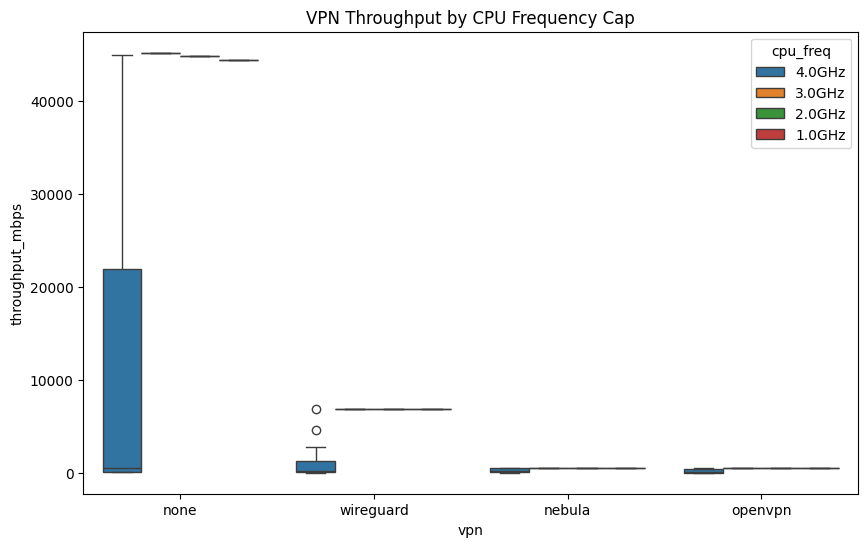

In [8]:
# Generates a beautiful Boxplot showing how different CPU frequencies cap throughput across protocols.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='vpn', y='throughput_mbps', hue='cpu_freq')
plt.title("VPN Throughput by CPU Frequency Cap")
plt.show()